--- Starting Corrected Feature Engineering: Agri Sentiment ---
Calculating AgSent_MA7, AgSent_MA30, and AgSent_Vol7...
Generating diagnostic graphs...


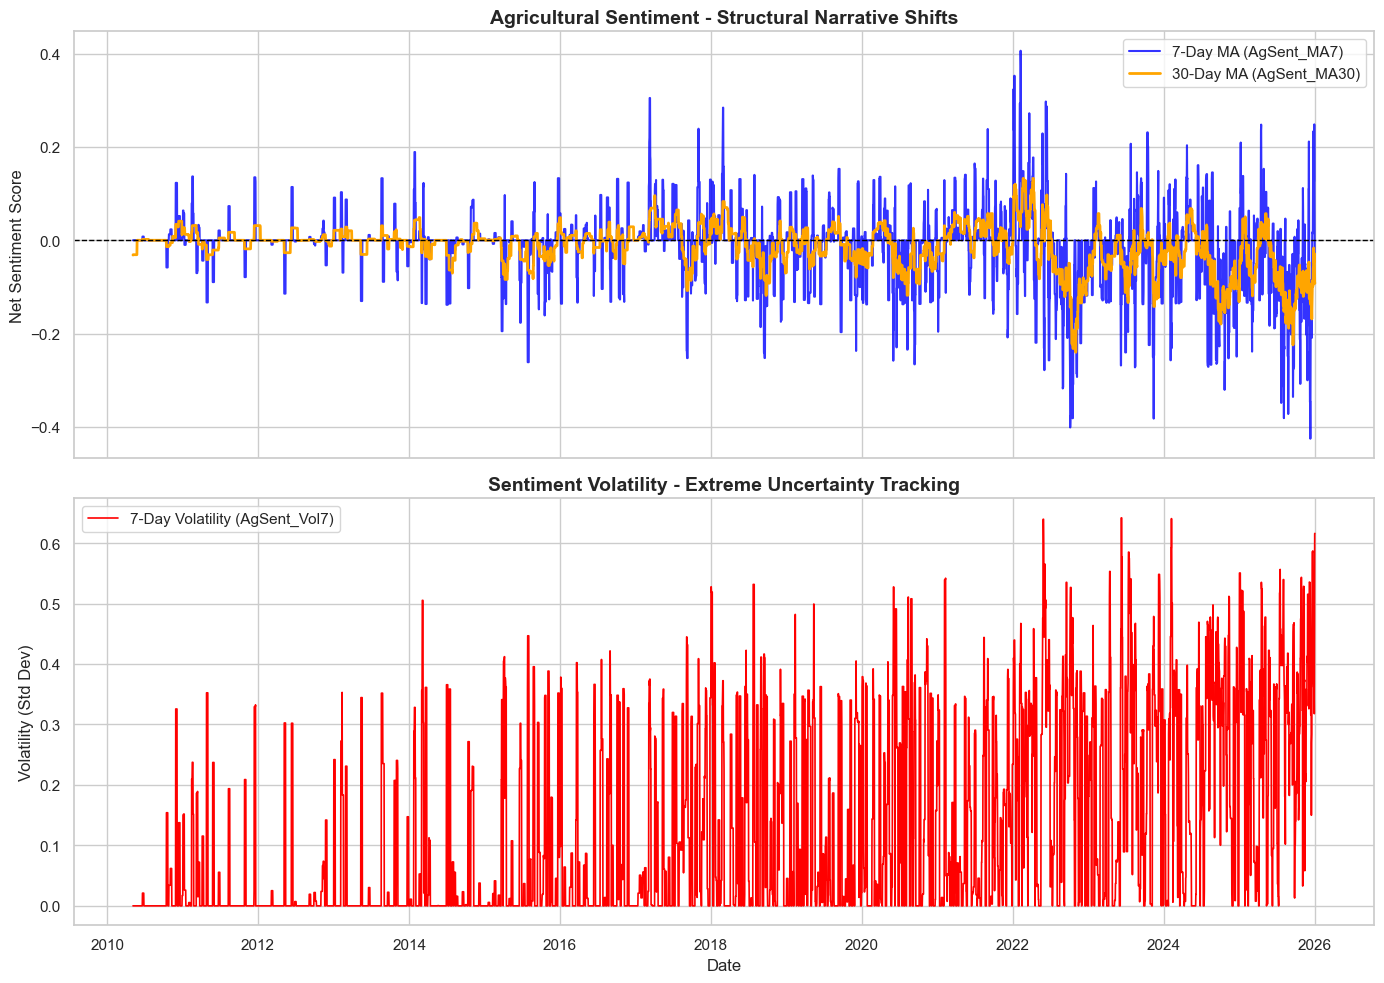


Success! Corrected Sentiment dataset saved to: D:\MS_Data_Science_Thesis\Data_Cleaning\Semi_Clean_Datasets\agri_sentiment_engineered_II.csv
           Date  Net_Sentiment  AgSent_MA7  AgSent_MA30  AgSent_Vol7
5744 2025-12-28       0.000000    0.126069    -0.045645     0.361891
5745 2025-12-29       0.510296    0.248380    -0.028635     0.317794
5746 2025-12-30      -0.635809    0.137388    -0.049829     0.463683
5747 2025-12-31      -0.962698   -0.036587    -0.092562     0.615693
5748 2026-01-01       0.022225   -0.033412    -0.091821     0.615971


In [8]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Directory Setup
base_dir = r"D:\MS_Data_Science_Thesis"
raw_folder = os.path.join(base_dir, r"Data_Extraction\Raw_Data_Folder")
clean_folder = os.path.join(base_dir, r"Data_Cleaning\Semi_Clean_Datasets")
os.makedirs(clean_folder, exist_ok=True)

input_file = os.path.join(raw_folder, "cotton_finbert_daily_scores.csv")

def engineer_sentiment_features_corrected():
    print("--- Starting Corrected Feature Engineering: Agri Sentiment ---")
    
    if not os.path.exists(input_file):
        print(f"Error: Could not find {input_file}")
        return

    # 2. Load Data
    df = pd.read_csv(input_file)
    df['Date'] = pd.to_datetime(df['Date'])
    
    # 3. Handle Weekend News (Shift to Monday)
    df['Date'] = np.where(df['Date'].dt.dayofweek == 5, df['Date'] + pd.Timedelta(days=2), df['Date'])
    df['Date'] = np.where(df['Date'].dt.dayofweek == 6, df['Date'] + pd.Timedelta(days=1), df['Date'])
    
    # Group by Date to average any weekend articles that landed on the same Monday
    df = df.groupby('Date')[['FinBERT_Positive', 'FinBERT_Negative', 'FinBERT_Neutral', 'Net_Sentiment']].mean().reset_index()
    
    # 4. Handle Sparsity (Create a continuous daily calendar)
    full_date_range = pd.date_range(start=df['Date'].min(), end=df['Date'].max(), freq='D')
    df_continuous = df.set_index('Date').reindex(full_date_range).rename_axis('Date').reset_index()
    
    # Fill missing days (No news = Neutral Net Sentiment of 0)
    df_continuous['Net_Sentiment'] = df_continuous['Net_Sentiment'].fillna(0)
    
    # 5. Complex Feature Generation (Methodology Aligned)
    print("Calculating AgSent_MA7, AgSent_MA30, and AgSent_Vol7...")
    
    # 7-day and 30-day Simple Moving Averages
    df_continuous['AgSent_MA7'] = df_continuous['Net_Sentiment'].rolling(window=7).mean()
    df_continuous['AgSent_MA30'] = df_continuous['Net_Sentiment'].rolling(window=30).mean()
    
    # 7-day Sentiment Volatility (Standard Deviation)
    df_continuous['AgSent_Vol7'] = df_continuous['Net_Sentiment'].rolling(window=7).std()
    
    # 6. Clean Data
    # Drop the first 30 rows that contain NaNs from the MA30 calculation
    df_cleaned = df_continuous.dropna(subset=['AgSent_MA30', 'AgSent_Vol7']).copy()
    
    # 7. Data Visualization
    print("Generating diagnostic graphs...")
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    
    # Top Plot: Sentiment MA7 and MA30
    ax1.plot(df_cleaned['Date'], df_cleaned['AgSent_MA7'], color='blue', linewidth=1.5, alpha=0.8, label='7-Day MA (AgSent_MA7)')
    ax1.plot(df_cleaned['Date'], df_cleaned['AgSent_MA30'], color='orange', linewidth=2, label='30-Day MA (AgSent_MA30)')
    ax1.axhline(0, color='black', linewidth=1, linestyle='--')
    ax1.set_title('Agricultural Sentiment - Structural Narrative Shifts', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Net Sentiment Score', fontsize=12)
    ax1.legend()
    
    # Bottom Plot: Sentiment Volatility
    ax2.plot(df_cleaned['Date'], df_cleaned['AgSent_Vol7'], color='red', linewidth=1.2, label='7-Day Volatility (AgSent_Vol7)')
    ax2.set_title('Sentiment Volatility - Extreme Uncertainty Tracking', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Volatility (Std Dev)', fontsize=12)
    ax2.set_xlabel('Date', fontsize=12)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # 8. Export the intermediate dataset
    output_path = os.path.join(clean_folder, "agri_sentiment_engineered_II.csv")
    
    # Keep essential columns for the master merge
    cols_to_keep = ['Date', 'Net_Sentiment', 'AgSent_MA7', 'AgSent_MA30', 'AgSent_Vol7']
    df_export = df_cleaned[cols_to_keep]
    
    df_export.to_csv(output_path, index=False)
    
    print(f"\nSuccess! Corrected Sentiment dataset saved to: {output_path}")
    print(df_export.tail())

if __name__ == "__main__":
    engineer_sentiment_features_corrected()